<a href="https://colab.research.google.com/github/anjicx/ComorbidityNetworkGNN/blob/main/GRAPHS%2CPROPERTIES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#imports
import pandas as pd
import numpy as np
import random
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
adj_matrices = {}
# made a dict 1:list of loaded matrix
for i in range(1, 9):
    path = f'/content/drive/MyDrive/Adj_Matrix_Age_ICD_Male/Adj_Matrix_Male_ICD_age_{i}.csv'
    adj_matrices[i] = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    print(f"Age group {i}: shape {adj_matrices[i].shape}")


Age group 1: shape (1080, 1080)
Age group 2: shape (1080, 1080)
Age group 3: shape (1080, 1080)
Age group 4: shape (1080, 1080)
Age group 5: shape (1080, 1080)
Age group 6: shape (1080, 1080)
Age group 7: shape (1080, 1080)
Age group 8: shape (1080, 1080)


In [ ]:
def normalize_matrix(df):
    for i in range(df.shape[0]):    # for each disease raw
        row_sum = df[i, :].sum()     # summ this disease with all
        if row_sum > 0:                  # skip diseases with no connections-for dividing with 0
            df[i, :] = df[i, :] / row_sum  # divide each value by the total
    return df

In [ ]:
normalized_matrices={}
for i in range(1, 9):                          # for each age group 1-8
    raw = adj_matrices[i].values.copy()         # cpy
    norm = normalize_matrix(raw)  # NORMALIZATION
    normalized_matrices[i] = np.maximum(norm, norm.T) # SYMETRIC
    #MAX MEAN GNN WRITE

In [ ]:
df = pd.DataFrame(normalized_matrices[1])
#df.iloc[:10, :10]
u=0
for i in range(1, 9):
    A = normalized_matrices[i]
    #non_zero = np.count_nonzero(A)
    undirected_edges = np.count_nonzero(np.triu(A, k=1))
    u+=undirected_edges
    print(f"Age group {i}")
    #print("non-zero cells:", non_zero)
    print("undirected edges:", undirected_edges)
    print()
#NUMBER OF ALL POSSIBLE EDGES IN EACH GROUP
entries=df.shape[0]*(df.shape[0]-1) //2 #squared and times i because we have it i times for i age groups
print(f"Out of total possible undirected edges accross all 8 groups: {entries*i}, we have: {u}")

Age group 1
undirected edges: 425

Age group 2
undirected edges: 120

Age group 3
undirected edges: 312

Age group 4
undirected edges: 631

Age group 5
undirected edges: 1489

Age group 6
undirected edges: 2456

Age group 7
undirected edges: 3224

Age group 8
undirected edges: 3663

Out of total possible undirected edges accross all 8 groups: 4661280, we have: 12320


In [ ]:
!pip install igraph
#GRAPH AND ITS PROPERTIES

import igraph as ig

age_labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]
graphs = {}

properties = pd.DataFrame({
    'Age': list(range(1, 9)),
    'Age_label': age_labels,
    'nodes': None,
    'degree': None,
    'avg_path_length': None,
    'betweenness': None,
    'closeness': None,
    'density': None,
    'modularity': None
})

for i in range(1, 9):
    graphs[i] = ig.Graph.Weighted_Adjacency(normalized_matrices[i].tolist(), mode="max", attr="weight")

    raw = adj_matrices[i].values
    idx = i - 1

    # Connected nodes
    non_zero_nodes = np.where((raw.sum(axis=0) != 0) | (raw.sum(axis=1) != 0))[0]
    properties.at[idx, 'nodes'] = len(non_zero_nodes)

    # Average degree
    row_sums = (raw != 0).sum(axis=1)
    non_zero_degrees = row_sums[row_sums != 0]
    properties.at[idx, 'degree'] = np.mean(non_zero_degrees)

    # Average path length
    shortest_paths = graphs[i].distances()
    finite_lengths = [l for row in shortest_paths for l in row if l < float('inf')]
    properties.at[idx, 'avg_path_length'] = np.mean(finite_lengths) if finite_lengths else float('nan')

    # Betweenness
    properties.at[idx, 'betweenness'] = np.mean(graphs[i].betweenness())

    # Closeness
    closeness = graphs[i].closeness(normalized=True)
    closeness_clean = [v if not np.isinf(v) else 0 for v in closeness]
    properties.at[idx, 'closeness'] = np.nanmean(closeness_clean)

    # Density
    properties.at[idx, 'density'] = graphs[i].density()

    # Modularity
    communities = graphs[i].community_multilevel()
    properties.at[idx, 'modularity'] = graphs[i].modularity(communities)

    print(f"Age {age_labels[i-1]} done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 26.9 MB/s eta 0:00:00
Age 0-9 done
Age 10-19 done
Age 20-29 done
Age 30-39 done
Age 40-49 done
Age 50-59 done
Age 60-69 done
Age 70-79 done


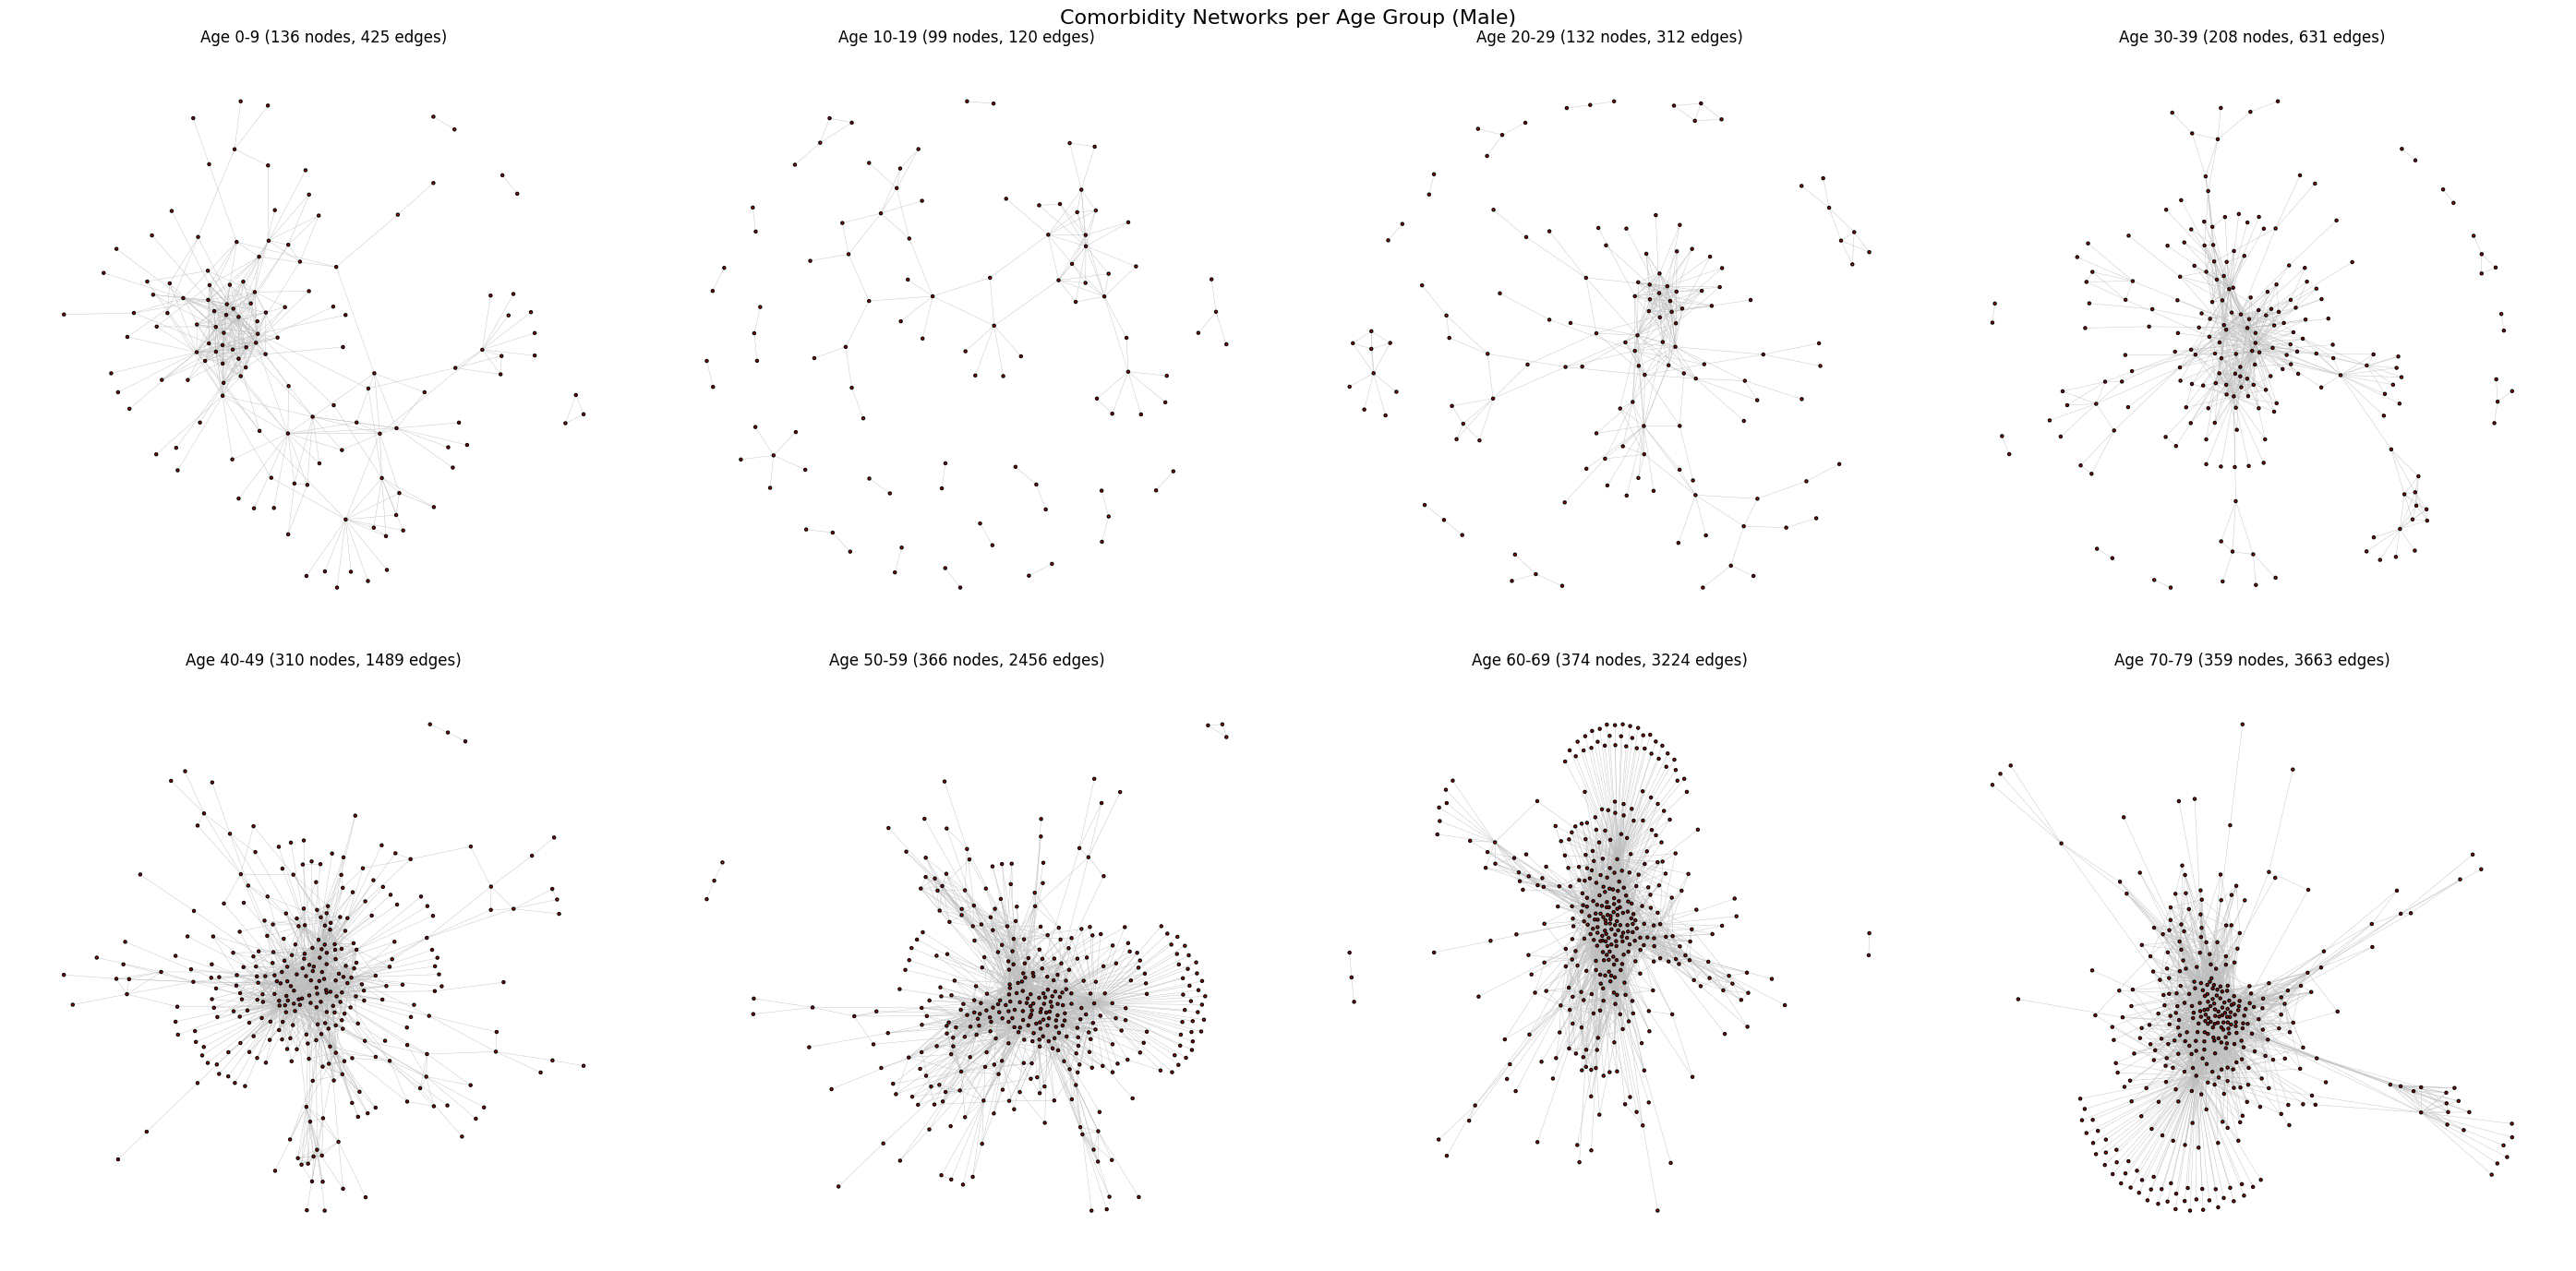

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(28, 14))
age_labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]

for i in range(1, 9):
    ax = axes[(i-1)//4, (i-1)%4]

    #INCLUDING ONLY NODES WITH AT LEAST 1 EDGE
    g = graphs[i]
    connected = [v.index for v in g.vs if g.degree(v.index) > 0]
    subgraph = g.subgraph(connected)

    # Layout
    layout = subgraph.layout("fruchterman_reingold")

    # Plot
    ig.plot(subgraph, target=ax, layout=layout,
            vertex_size=3,
            edge_width=0.3,
            vertex_color="red",
            edge_color="gray")

    ax.set_title(f"Age {age_labels[i-1]} ({len(connected)} nodes, {subgraph.ecount()} edges)")

plt.suptitle("Comorbidity Networks per Age Group (Male)", fontsize=16)
plt.tight_layout()
plt.show()